In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("artists_data_raw.csv")

df.head()

,mbid,name,type,gender,area_name,begin_date,end_date,ended,tags,genre_label,label_count,release_rel_count,album_count
0,89ad4ac3-39f7-470e-963a-56509c546377,Various Artists,Other,NaN,NaN,NaN,NaN,NaN,"['compilation', 'country dreams', 'special pur...",rock,4,3,0
1,70248960-cb53-4ea4-943a-edb18f7d336f,Bruce Springsteen,Person,Male,United States,1949-09-23,NaN,NaN,"['american', 'americana', 'aor', 'big music', ...",rock,1,1511,21
2,b10bbbfc-cf9e-42e0-be17-e2c3e1d2600d,The Beatles,Group,NaN,United Kingdom,1960,1970-04-10,True,"['60s', 'beat', 'british', 'british invasion',...",rock,2,0,20
3,d6652e7b-33fe-49ef-8336-4c863b4f996f,The E Street Band,Group,NaN,United States,1972-10,NaN,NaN,"['heartland rock', 'pop rock', 'rock']",rock,0,0,0
4,b071f9fa-14b0-4217-8e97-eb41da73f598,The Rolling Stones,Group,NaN,United Kingdom,1962,NaN,NaN,"['blues', 'blues rock', 'british', 'british rh...",rock,2,8,25


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   mbid               2000 non-null   str   
 1   name               2000 non-null   str   
 2   type               1999 non-null   str   
 3   gender             1225 non-null   str   
 4   area_name          1985 non-null   str   
 5   begin_date         1927 non-null   str   
 6   end_date           646 non-null    str   
 7   ended              652 non-null    object
 8   tags               2000 non-null   str   
 9   genre_label        2000 non-null   str   
 10  label_count        2000 non-null   int64 
 11  release_rel_count  2000 non-null   int64 
 12  album_count        2000 non-null   int64 
dtypes: int64(3), object(1), str(9)
memory usage: 203.3+ KB


In [20]:
df.describe()

,label_count,release_rel_count,album_count
count,2000.000000,2000.000000,2000.000000
mean,1.002000,25.137000,16.494000
std,1.675828,81.616352,7.563635
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,10.000000
50%,0.000000,5.000000,17.000000
75%,1.000000,18.000000,24.000000
max,16.000000,1511.000000,25.000000


In [21]:
df.isnull().sum()

mbid                    0
name                    0
type                    1
gender                775
area_name              15
begin_date             73
end_date             1354
ended                1348
tags                    0
genre_label             0
label_count             0
release_rel_count       0
album_count             0
dtype: int64

### Deduplication of Name Feature

In [22]:
len(df.name.unique())

1499

In [23]:
agg_funcs = {col: 'first' for col in df.columns if col not in ['name', 'genre_label']}
agg_funcs['genre_label'] = lambda x: list(set(x.dropna()))

df = df.groupby('name', as_index = False).agg(agg_funcs)
print(f"Number of rows after deduplication: {len(df)}")
display(df[['name', 'genre_label']].head(5))

Number of rows after deduplication: 1499


,name,genre_label
0,$WAGGOT,[electronic]
1,10cc,"[rock, pop]"
2,2 Chainz,[hip hop]
3,2 Mello,[hip hop]
4,2 Unlimited,"[hip hop, electronic]"


### Updating null values for Type feature

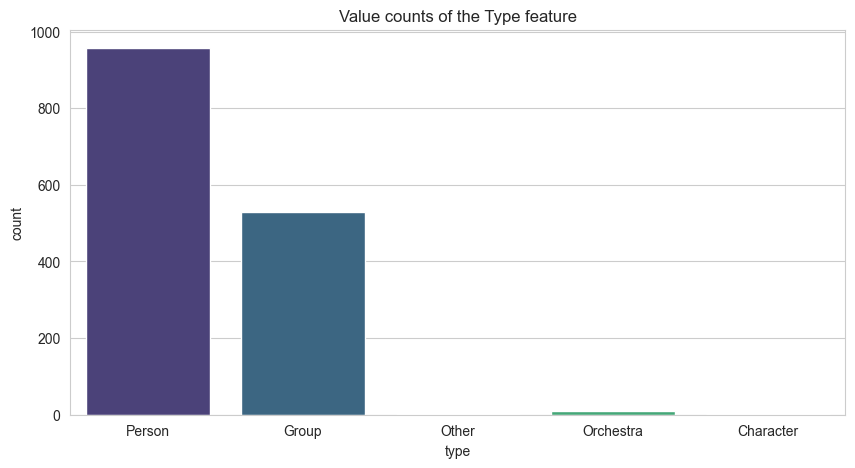

In [24]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='type', palette='viridis', hue = 'type', legend = False)
plt.title('Value counts of the Type feature')
plt.show()

In [25]:
df[df.type.isnull()]

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label
1152,Sirch,e065954f-0724-4fd7-acaf-f36ac631a9bb,NaN,NaN,Derry,NaN,NaN,None,"['edm', 'electronic', 'industrial', 'punk', 't...",0,0,24,[electronic]


In [26]:
sirch_mbid = 'e065954f-0724-4fd7-acaf-f36ac631a9bb'
df.loc[df['mbid'] == sirch_mbid, 'type'] = 'Person'
print(f"Fixed type for artist Sirch. New type is: {df.loc[df['mbid'] == sirch_mbid, 'type'].values[0]}")

Fixed type for artist Sirch. New type is: Person


### Gender

In [27]:
df.gender.value_counts(dropna = False)

gender
Male              802
NaN               542
Female            152
Non-binary          2
Not applicable      1
Name: count, dtype: int64

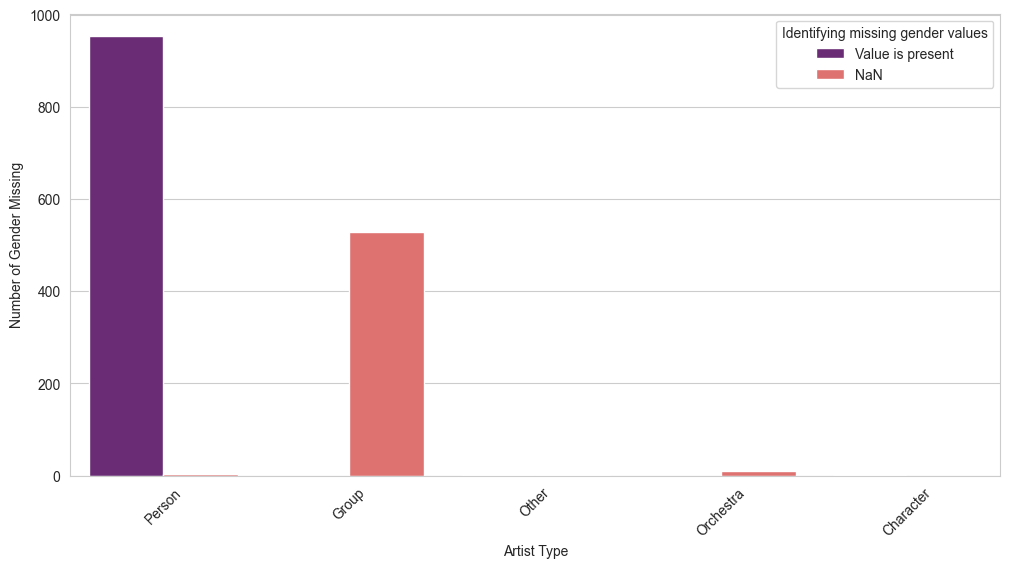

In [28]:
df['is_gender_missing'] = df['gender'].isnull()

plt.figure(figsize = (12, 6))
sns.countplot(data = df, x = 'type', hue = 'is_gender_missing', palette = 'magma')

plt.xlabel('Artist Type')
plt.ylabel('Number of Gender Missing')
plt.legend(title='Identifying missing gender values', labels=['Value is present', 'NaN'])
plt.xticks(rotation=45)
plt.show()

In [29]:
df.drop(columns = ['is_gender_missing'], inplace = True)

In [30]:
df.loc[((df['type'] == 'Group') | (df['type'] == 'Orchestra')) & (df['gender'].isnull()), 'gender'] = 'Not applicable'
df['gender'] = df['gender'].fillna('Other/Unknown')
df['gender'] = df['gender'].replace('Non-binary', 'Other/Unknown')
print("Final gender distribution:")
print(df['gender'].value_counts())

Final gender distribution:
gender
Male              802
Not applicable    538
Female            152
Other/Unknown       7
Name: count, dtype: int64


### Area Name

In [31]:
df['area_name'].value_counts()

area_name
United States     779
United Kingdom    241
Germany            95
France             52
Japan              51
                 ... 
Honolulu            1
Kentucky            1
Perth               1
Taiwan              1
North Korea         1
Name: count, Length: 85, dtype: int64

In [32]:
df.loc[df['area_name'] == 'North Korea']

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label
1497,보천보전자악단,cd72e086-d7a8-4fd8-a6b8-829229a28e8c,Orchestra,Not applicable,North Korea,1985-06-04,2012,True,"['dprk-pop', 'juche', 'pop', 'propaganda']",0,0,25,[pop]


In [33]:
country_mapper = {
    'England': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'Wales': 'United Kingdom',
    'Northern Ireland': 'United Kingdom',
    'London': 'United Kingdom',
    'Perth': 'Australia',
    'Kingdom of the Netherlands': 'Netherlands',
    'Hammerfest': 'Norway',
    'Berlin': 'Germany',
    'Köln': 'Germany',
    'Hamburg': 'Germany',
    'München': 'Germany',
    'Bochum': 'Germany',
    'Leese': 'Germany',
    'Furtwangen im Schwarzwald': 'Germany',
    'New York': 'United States',
    'California': 'United States',
    'Los Angeles': 'United States',
    'Hoboken': 'United States',
    'Detroit': 'United States',
    'Queensbridge': 'United States',
    'Manhattan': 'United States',
    'Brooklyn': 'United States',
    'Derry': 'United States',
    'Del Mar': 'United States',
    'Kentucky': 'United States',
    'Louisville': 'United States',
    'Maryland': 'United States',
    'Burbank': 'United States',
    'Illinois': 'United States',
    'Bentonville': 'United States',
    'Rochester': 'United States',
    'Miami': 'United States',
    'Saddle River': 'United States',
    'Hayward': 'United States',
    'Newark': 'United States',
    'Buffalo': 'United States',
    'Memphis': 'United States',
    'Long Island': 'United States',
    'New Jersey': 'United States',
    'Nashville': 'United States',
    'Houston': 'United States',
    'Honolulu': 'United States',
    'Mumbai': 'India',
    'Osaka': 'Japan',
}

In [34]:
df['area_name'] = df['area_name'].replace(country_mapper)
df['area_name'].value_counts()

area_name
United States     823
United Kingdom    262
Germany           103
Japan              52
France             52
Canada             34
Netherlands        28
Italy              20
Australia          16
Belgium            11
Jamaica             9
Brazil              8
Sweden              7
Russia              6
Norway              6
Switzerland         5
Austria             4
Ireland             4
South Korea         3
Finland             3
Spain               3
Denmark             3
Greece              3
Hong Kong           3
South Africa        2
Iceland             2
Hungary             2
Argentina           2
Senegal             1
India               1
China               1
Israel              1
Czechia             1
Slovenia            1
Cameroon            1
Cuba                1
Colombia            1
Monte-Carlo         1
[Worldwide]         1
Taiwan              1
North Korea         1
Name: count, dtype: int64

In [35]:
regional_mapper = {
    'United States': 'North America',
    'Canada': 'North America',
    'Jamaica': 'North America',
    'United Kingdom': 'United Kingdom',
    'Germany': 'Europe (Excl. UK)',
    'France': 'Europe (Excl. UK)',
    'Netherlands': 'Europe (Excl. UK)',
    'Italy': 'Europe (Excl. UK)',
    'Belgium': 'Europe (Excl. UK)',
    'Sweden': 'Europe (Excl. UK)',
    'Ireland': 'Europe (Excl. UK)',
    'Norway': 'Europe (Excl. UK)',
    'Iceland': 'Europe (Excl. UK)',
    'Switzerland': 'Europe (Excl. UK)',
    'Greece': 'Europe (Excl. UK)',
    'Austria': 'Europe (Excl. UK)',
    'Monte-Carlo': 'Europe (Excl. UK)',
    'Finland': 'Europe (Excl. UK)',
    'Denmark': 'Europe (Excl. UK)',
    'Span': 'Europe (Excl. UK)',
    'Hungary': 'Europe (Excl. UK)',
    'Slovenia': 'Europe (Excl. UK)',
    'Czechia': 'Europe (Excl. UK)',
    'Spain': 'Europe (Excl. UK)',
    'Japan': 'Asia',
    'Russia': 'Asia',
    'Hong Kong': 'Asia',
    'South Korea': 'Asia',
    'China': 'Asia',
    'Taiwan': 'Asia',
    'India': 'Asia',
    'North Korea': 'Asia',
    'Australia': 'Rest of World',
    'Brazil': 'Rest of World',
    'Argentina': 'Rest of World',
    'South Africa': 'Rest of World',
    'Israel': 'Rest of World',
    'Cameroon': 'Rest of World',
    'Senegal': 'Rest of World',
    'Colombia': 'Rest of World',
    'Cuba': 'Rest of World'
}

In [36]:
df = df.drop(df[df['area_name'] == '[Worldwide]'].index)
df['area_name'] = df['area_name'].replace(regional_mapper)
df['area_name'].value_counts()

area_name
North America        866
United Kingdom       262
Europe (Excl. UK)    259
Asia                  68
Rest of World         33
Name: count, dtype: int64

In [37]:
df[df['area_name'].isnull()]

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label
0,$WAGGOT,41fabc90-d6d9-4783-8927-1eebad975ea5,Person,Male,NaN,????-02-14,NaN,None,"['dark wave', 'darkwave', 'electronic', 'gay',...",5,20,25,[electronic]
927,Nelson Riddle and His Orchestra,a75df285-0e05-4d81-9939-5f86f15babf9,Orchestra,Not applicable,NaN,NaN,NaN,None,['jazz'],0,1,14,[jazz]
1002,Pete „Wyoming“ Bender,3ee109d7-0b35-4d4d-82f1-ed693f3d1124,Person,Male,NaN,1943-09-14,2014-02-15,True,"['electronic', 'funk', 'rock']",0,2,25,[electronic]
1048,Radio Massacre International,9581ec7c-07a5-4a7e-89b3-bac51720d404,Group,Not applicable,NaN,1993,NaN,None,"['electronic', 'experimental', 'organic music']",1,0,23,[electronic]
1204,System F,4bee86b5-95c4-429a-8489-353516f815ab,Person,Male,NaN,NaN,NaN,None,"['electronic', 'trance']",0,0,2,[electronic]
1232,The BBC Radiophonic Workshop,39f0d457-37ba-43b9-b0a9-05214bae5d97,Group,Not applicable,NaN,1958-04-01,1998,True,"['dance and electronica', 'electronic']",1,3,6,[electronic]
1237,The Benny Goodman Sextet,82eb0cc2-84be-44b2-8b5d-543e3a1a4003,Group,Not applicable,NaN,NaN,NaN,None,"['big band', 'jazz', 'swing']",0,0,2,[jazz]
1385,Various Artists,89ad4ac3-39f7-470e-963a-56509c546377,Other,Other/Unknown,NaN,NaN,NaN,None,"['compilation', 'country dreams', 'special pur...",4,3,0,"[hip hop, electronic, jazz, rock, pop]"
1392,WadeLen,6c790bba-0ca6-44ca-8334-d1cd9c860eb1,Person,Male,NaN,NaN,NaN,None,"['electronic rock', 'instrumental']",1,521,16,"[rock, electronic]"
1458,user-177606669,e9440cc5-06ac-4042-b3ac-fc47c82b1357,Group,Not applicable,NaN,NaN,NaN,None,"['!hyperfocus', 'digicore', 'electronic', 'hyp...",0,0,25,[electronic]


In [38]:
df = df.dropna(subset = ['area_name'], how = 'all')
df[df['area_name'].isnull()]

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label


### Carrier Time

In [39]:
df['begin_date'].value_counts(dropna = False)

begin_date
NaN           59
1983          18
1991          17
1989          16
1988          15
              ..
1953-01-29     1
1953-03-27     1
1957-08-29     1
1985-06-04     1
1995-10-03     1
Name: count, Length: 1054, dtype: int64

In [40]:
df['end_date'].value_counts(dropna = False)

end_date
NaN           1017
2022             5
1986             4
2006             4
2000             3
              ... 
2022-12-29       1
2001-01-23       1
2016-05-05       1
2023-03-28       1
1995-05-08       1
Name: count, Length: 422, dtype: int64

In [41]:
def extract_year(date_series):
    return pd.to_numeric(date_series.astype(str).str[:4], errors='coerce')
df['begin_year'] = extract_year(df['begin_date'])
df['end_year'] = extract_year(df['end_date'])

display(df[['name', 'begin_date', 'begin_year', 'end_date', 'end_year']].head(10))

,name,begin_date,begin_year,end_date,end_year
1,10cc,1972,1972.0,NaN,NaN
2,2 Chainz,1976-09-10,1976.0,NaN,NaN
3,2 Mello,NaN,NaN,NaN,NaN
4,2 Unlimited,1991-05,1991.0,NaN,NaN
5,2Pac,1971-06-16,1971.0,1996-09-13,1996.0
6,311,1988,1988.0,NaN,NaN
7,4 Strings,NaN,NaN,NaN,NaN
8,50 Cent,1975-07-06,1975.0,NaN,NaN
9,808 State,1988,1988.0,NaN,NaN
10,9th Wonder,1975-01-15,1975.0,NaN,NaN


In [42]:
print(df[['begin_year', 'end_year']].describe())

        begin_year     end_year
count  1429.000000   471.000000
mean   1964.337299  1998.146497
std      24.922336    20.758433
min    1868.000000  1917.000000
25%    1946.000000  1984.000000
50%    1970.000000  2002.000000
75%    1983.000000  2016.000000
max    2023.000000  2026.000000


In [43]:
logic_errors = df[df['end_year'] < df['begin_year']]

print(f"Records count with logical error: {len(logic_errors)}")
if len(logic_errors) > 0:
    display(logic_errors[['name', 'begin_year', 'end_year']])

Records count with logical error: 0


In [44]:
inconsistent_records = df[(df['ended'] == True) & (df['end_date'].isna())]

print(f"Inconsistent records count: {len(inconsistent_records)}")

if len(inconsistent_records) > 0:
    display(inconsistent_records[['name', 'ended', 'end_date', 'begin_date']])

Inconsistent records count: 5


,name,ended,end_date,begin_date
400,Duke Ellington and His Orchestra,True,NaN,1927
793,Louis Armstrong & His All-Stars,True,NaN,1947-08-13
1038,Queen,True,NaN,1970-06-27
1271,The Jacksons,True,NaN,1966
1291,The Oscar Peterson Trio,True,NaN,1946


In [45]:
df.loc[df['name'].str.contains('Duke Ellington and His Orchestra', na=False), 'end_year'] = 1974
df.loc[df['name'].str.contains('Louis Armstrong & His All-Stars', na=False), 'end_year'] = 1971
df.loc[df['name'].str.contains('The Oscar Peterson Trio', na=False), 'end_year'] = 1958
df.loc[df['name'] == 'Queen', 'ended'] = False
df.loc[df['name'] == 'The Jacksons', 'ended'] = False

In [47]:
df_exploded = df.explode('genre_label')
medians_df = df_exploded.groupby(['type', 'genre_label'])['begin_year'].median().reset_index()

def fill_missing_begin_year(row):
    if pd.notnull(row['begin_year']):
        return row['begin_year']

    artist_type = row['type']
    artist_genres = row['genre_label']

    if pd.isnull(artist_type) or not isinstance(artist_genres, list) or len(artist_genres) == 0:
        return np.nan

    matching_medians = medians_df[
        (medians_df['type'] == artist_type) &
        (medians_df['genre_label'].isin(artist_genres))
    ]['begin_year']

    if not matching_medians.empty:
        return matching_medians.mean()
    else:
        return np.nan

df['begin_year'] = df.apply(fill_missing_begin_year, axis=1)

fallback_medians = df.groupby('type')['begin_year'].median().to_dict()
df['begin_year'] = df['begin_year'].fillna(df['type'].map(fallback_medians))
df['begin_year'] = df['begin_year'].fillna(df['begin_year'].median())

print(df['begin_year'].isna().sum())

0


In [48]:
df['begin_year'].value_counts()

begin_year
1977.0    53
1967.0    41
1968.0    38
1976.0    36
1982.0    35
          ..
1868.0     1
1897.0     1
1970.5     1
1905.0     1
2023.0     1
Name: count, Length: 124, dtype: int64

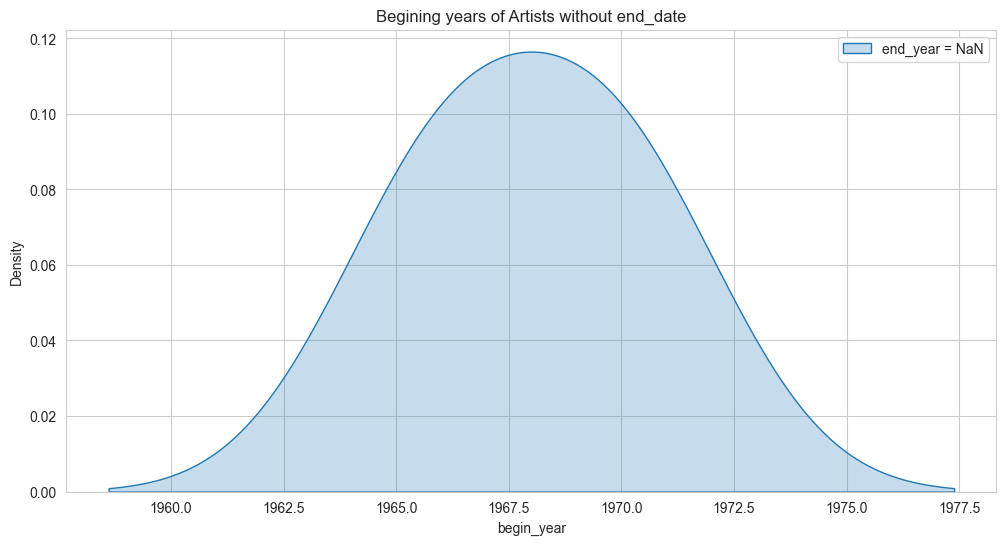

In [49]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df[df['ended'] == False], x='begin_year', label='end_year = NaN', fill=True)
plt.title('Begining years of Artists without end_date')
plt.xlabel('begin_year')
plt.ylabel('Density')
plt.legend()
plt.show()

In [50]:
completed_careers = df[df['end_year'].notna()].copy()
completed_careers['actual_longevity'] = completed_careers['end_year'] - completed_careers['begin_year']

print(completed_careers['actual_longevity'].describe())

count    474.000000
mean      53.668776
std       26.924646
min        0.000000
25%       31.000000
50%       57.000000
75%       77.000000
max       98.000000
Name: actual_longevity, dtype: float64


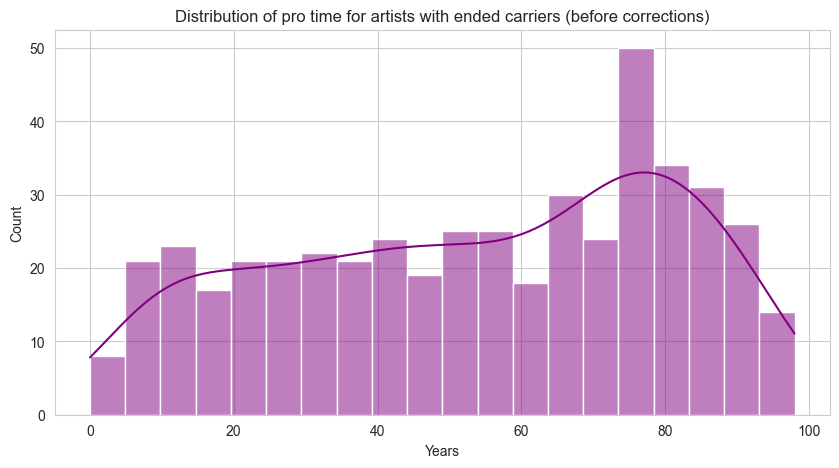

In [61]:
plt.figure(figsize=(10, 5))
sns.histplot(completed_careers['actual_longevity'], bins=20, kde=True, color='purple')
plt.title('Distribution of pro time for artists with ended carriers (before corrections)')
plt.xlabel('Years')
plt.show()

In [56]:
df.head()

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label,begin_year,end_year
1,10cc,f37c537b-3557-4031-bfd6-ab63ced32854,Group,Not applicable,United Kingdom,1972,NaN,None,"['1970s', '1980s', '1990s', 'aln-sh', 'art pop...",1,13,12,"[rock, pop]",1972.0,NaN
2,2 Chainz,dff0d392-4cd5-4052-9fbb-f485df3891e5,Person,Male,North America,1976-09-10,NaN,None,"['2010s', 'criminal', 'dirty south', 'hardcore...",5,4,19,[hip hop],1976.0,NaN
3,2 Mello,f5dd24ca-611d-4ad1-bb43-04601901ac0d,Person,Male,North America,NaN,NaN,None,"['big beat', 'breakbeat', 'hip hop', 'instrume...",1,5,15,[hip hop],1977.0,NaN
4,2 Unlimited,515b236c-cce1-4dc2-aedd-50de7b1736e2,Group,Not applicable,Europe (Excl. UK),1991-05,NaN,None,"['1 hit wonder', '1990s', '90s', 'edm', 'elect...",0,0,4,"[hip hop, electronic]",1991.0,NaN
5,2Pac,382f1005-e9ab-4684-afd4-0bdae4ee37f2,Person,Male,North America,1971-06-16,1996-09-13,True,"['90s', 'conscious hip hop', 'death by murder'...",0,0,11,[hip hop],1971.0,1996.0


In [57]:
df['end_year'] = df['end_year'].fillna(2026)

def calculate_pro_years(row):
    raw_diff = row['end_year'] - row['begin_year']
    if row['type'] == 'Person':
        pro_years = raw_diff - 18
    else:
        pro_years = raw_diff
    return max(pro_years, 1)

df['years_active_pro'] = df.apply(calculate_pro_years, axis=1)
print("Average pro time for types")
print(df.groupby('type')['years_active_pro'].mean().round(1))

Average pro time for types
type
Character    19.0
Group        36.8
Orchestra    57.6
Other        56.0
Person       43.1
Name: years_active_pro, dtype: float64


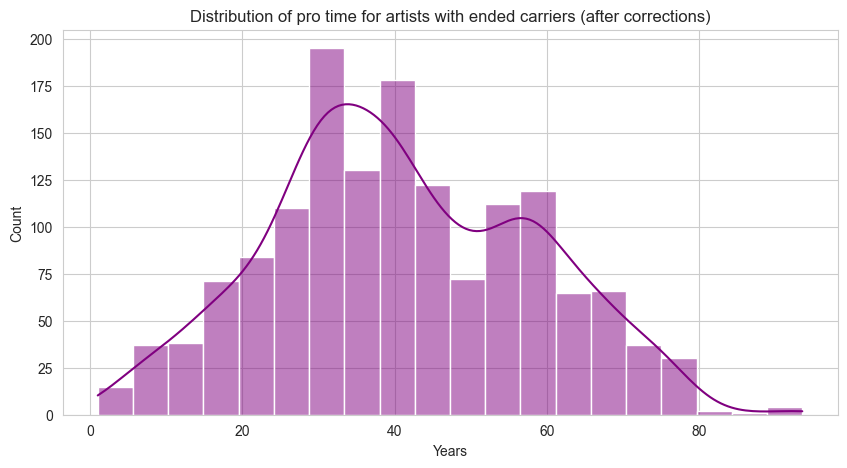

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(df['years_active_pro'], bins=20, kde=True, color='purple')
plt.title('Distribution of pro time for artists with ended carriers (after corrections)')
plt.xlabel('Years')
plt.show()

In [62]:
df.head()

,name,mbid,type,gender,area_name,begin_date,end_date,ended,tags,label_count,release_rel_count,album_count,genre_label,begin_year,end_year,years_active_pro
1,10cc,f37c537b-3557-4031-bfd6-ab63ced32854,Group,Not applicable,United Kingdom,1972,NaN,None,"['1970s', '1980s', '1990s', 'aln-sh', 'art pop...",1,13,12,"[rock, pop]",1972.0,2026.0,54.0
2,2 Chainz,dff0d392-4cd5-4052-9fbb-f485df3891e5,Person,Male,North America,1976-09-10,NaN,None,"['2010s', 'criminal', 'dirty south', 'hardcore...",5,4,19,[hip hop],1976.0,2026.0,32.0
3,2 Mello,f5dd24ca-611d-4ad1-bb43-04601901ac0d,Person,Male,North America,NaN,NaN,None,"['big beat', 'breakbeat', 'hip hop', 'instrume...",1,5,15,[hip hop],1977.0,2026.0,31.0
4,2 Unlimited,515b236c-cce1-4dc2-aedd-50de7b1736e2,Group,Not applicable,Europe (Excl. UK),1991-05,NaN,None,"['1 hit wonder', '1990s', '90s', 'edm', 'elect...",0,0,4,"[hip hop, electronic]",1991.0,2026.0,35.0
5,2Pac,382f1005-e9ab-4684-afd4-0bdae4ee37f2,Person,Male,North America,1971-06-16,1996-09-13,True,"['90s', 'conscious hip hop', 'death by murder'...",0,0,11,[hip hop],1971.0,1996.0,7.0


### Final Cleaning

In [70]:
import ast

df['tags'] = df['tags'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df['tag_count'] = df['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)

cols_to_keep = [
    'name', 'type', 'gender',
    'area_name', 'genre_label', 'album_count',
    'years_active_pro', 'label_count', 'tag_count',
    'release_rel_count'
]

df_clean = df[cols_to_keep].copy()
df_clean.info()
df_clean.to_csv('cleaned_data.csv', index=False)

<class 'pandas.DataFrame'>
Index: 1488 entries, 1 to 1498
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1488 non-null   str    
 1   type               1488 non-null   str    
 2   gender             1488 non-null   str    
 3   area_name          1488 non-null   str    
 4   genre_label        1488 non-null   object 
 5   album_count        1488 non-null   int64  
 6   years_active_pro   1488 non-null   float64
 7   label_count        1488 non-null   int64  
 8   tag_count          1488 non-null   int64  
 9   release_rel_count  1488 non-null   int64  
dtypes: float64(1), int64(4), object(1), str(4)
memory usage: 127.9+ KB
